importing all tools needed 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor 
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error , mean_absolute_percentage_error,r2_score
from sklearn.inspection import permutation_importance 


In [4]:
demand_file = pd.read_excel( r"C:\Users\mistr\Downloads\PGCB_date_power_demand.xlsx")
print(demand_file.shape)
demand_file.head(2)

(92650, 15)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


checking for duplicate time rows and removing duplicaates 

In [5]:
demand_file['datetime'] = pd.to_datetime(demand_file['datetime'])
demand_file = demand_file.sort_values('datetime')
demand_file = demand_file.reset_index(drop = True)
#-------- to get no. of duplicate file ------------
count = demand_file.duplicated(subset = 'datetime').sum()    
print(count)
#---- keeping first row and removing others ----------
demand_file = demand_file.drop_duplicates(subset = 'datetime' , keep = 'first')
print(demand_file.shape)
demand_file.head()

432
(92218, 15)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


checking if there irregularity in time interval

In [6]:
demand_file['datetime'].diff().value_counts() 

datetime
0 days 01:00:00     83649
0 days 00:30:00      8336
0 days 02:00:00       178
0 days 03:00:00        11
0 days 01:30:00         8
0 days 07:00:00         4
0 days 11:00:00         4
0 days 10:00:00         4
0 days 09:00:00         4
0 days 12:00:00         4
0 days 08:00:00         3
0 days 13:00:00         3
0 days 04:00:00         2
21 days 14:00:00        1
0 days 06:00:00         1
1 days 01:00:00         1
0 days 19:00:00         1
0 days 15:00:00         1
1 days 03:00:00         1
0 days 05:00:00         1
Name: count, dtype: int64

In [7]:
#------------- regularizing time intervals -------------#
demand_file = demand_file.set_index('datetime')
#---- taking numeric cols only for taking mean -----------
numeric_cols = demand_file.select_dtypes(include=np.number).columns.tolist()
#--------- converting datetime frequency into hourly and if more than one entry present then taking mean 
demand_file = demand_file[numeric_cols].resample('1h').mean()
demand_file = demand_file.reset_index() 
demand_file.head()
print(demand_file['demand_mw'].isna().sum())
demand_file['datetime'].diff().value_counts()

1051


datetime
0 days 01:00:00    89100
Name: count, dtype: int64

As shown in analysis of enegy file outliers and annoymous value are persent 


In [8]:
#---------------- removal of outliers----------------
def clean_outliers(col , k = 3) :
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1 
    lower = q1 - (k * iqr)
    higher = q3 + (k * iqr)
    outlier_range = ( col < lower ) | (col > higher)
    col_copy = col.copy()
    col_copy[outlier_range] = np.nan
    return col_copy

demand_file['demand_mw'] = clean_outliers(demand_file['demand_mw'], k=3)
demand_file['generation_mw'] = clean_outliers(demand_file['generation_mw'], k=3)

demand_file['demand_mw'].describe()

count    88042.000000
mean      8776.632687
std       2613.220034
min          6.000000
25%       6775.000000
50%       8385.000000
75%      10599.000000
max      20587.000000
Name: demand_mw, dtype: float64

only in case of demand and generation we using linear method as they are practically continiious values and more no. of outliers are present whereas in otther cols  very less outliers present and these values are practically non coontinious so  are repalced with 0    

In [9]:
#-----------  nan values are replaced using linear methods and forward fill and backward fill -------------------
demand_file['demand_mw'] = demand_file['demand_mw'].interpolate( method = 'linear' ,limit = 6).ffill().bfill()
demand_file['generation_mw'] = demand_file['generation_mw'].interpolate( method = 'linear', limit = 6).ffill().bfill()
print(demand_file['demand_mw'].isna().sum())
print(demand_file['generation_mw'].isna().sum())

for col in ['solar', 'wind', 'india_adani', 'nepal']:
    if col in demand_file.columns:
        demand_file[col] = demand_file[col].fillna(0)   
        print(demand_file[col].isna().sum())
        

0
0
0
0
0
0


In [10]:
weather_file = pd.read_excel(r"C:\Users\mistr\Downloads\weather_data.xlsx" , skiprows = 3)
weather_file.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [11]:
print (weather_file.columns.get_loc('time'))  #----- to confirm after removing 3 rows time got the 0th index
weather_file.columns

0


Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')

In [12]:
#----------------- renaming cols for more readability---------------------
weather_file.rename(columns={
                              'time' : 'datetime',
                              'temperature_2m (°C)' : 'temperature' ,
                              'relative_humidity_2m (%)' : 'humidity' ,
                              'apparent_temperature (°C)' : 'apperant_tempareture' ,
                              'precipitation (mm)' : 'precipitation' ,
                              'dew_point_2m (°C)' : 'dew_point' ,
                              'soil_temperature_0_to_7cm (°C)' : 'soil_temperature' ,
                              'wind_direction_10m (°)' : 'wind_direction' ,
                              'cloud_cover (%)'  : 'cloud_cover' ,
                              'sunshine_duration (s)' : 'sunshine_duration' 
                              },inplace= True)

In [13]:
print(weather_file.shape)
print(weather_file.dtypes)
weather_file.head()


(107304, 10)
datetime                datetime64[ns]
temperature                    float64
humidity                         int64
apperant_tempareture           float64
precipitation                  float64
dew_point                      float64
soil_temperature               float64
wind_direction                   int64
cloud_cover                      int64
sunshine_duration              float64
dtype: object


,datetime,temperature,humidity,apperant_tempareture,precipitation,dew_point,soil_temperature,wind_direction,cloud_cover,sunshine_duration
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


in order to make the economic file more readable for the the model 
1) taking inly imp rows 
2) renaming them for mmore clarity 
3) years are given cols wise so twisting it and making years into rows so model can read the pattern of a year easily

In [14]:
economic_file = pd.read_csv(r"C:\Users\mistr\Downloads\economic_full_1.csv")
imp_indicators = {
                         'NY.GDP.MKTP.KD':    'gdp_constant',
                         'NY.GDP.PCAP.KD':    'gdp_per_capita',
                         'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
                         'FP.CPI.TOTL.ZG':    'inflation',
                         'SP.POP.TOTL':       'population',
                         'SP.URB.TOTL.IN.ZS': 'urban_pct',
                         'EG.ELC.ACCS.ZS':    'electricity_access_pct',
                         'NV.IND.TOTL.ZS':    'industry_gdp_pct',
                         'EG.USE.PCAP.KG.OE': 'energy_use_per_capita',
                         'EG.USE.ELEC.KH.PC': 'elec_consumption_per_capita',
                         'EG.EGY.PRIM.PP.KD': 'energy_intensity',
                         'EG.FEC.RNEW.ZS':    'renewable_share',
                         'NV.IND.MANF.ZS':    'manufacturing_pct',
                         'NV.AGR.TOTL.ZS':    'agriculture_pct',
                         'NV.SRV.TOTL.ZS':    'services_pct',
                         'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct',
                         'NE.EXP.GNFS.ZS':    'exports_pct',
                         'EG.ELC.LOSS.ZS':    'grid_losses',
                         #'EN.ATM.CO2E.PC':    'co2_emissions',
                         'EG.USE.COMM.CL.ZS': 'clean_energy_pct'

}
#---------- keeping only imp rows ----------------------
economic_file = economic_file[economic_file['Indicator Code'].isin(imp_indicators.keys())]
print(economic_file.shape)
years = []
for y in range (2006 , 2026) :
    y = str(y)
    if y in economic_file.columns :
        years.append(y)
economic_file = economic_file[['Indicator Code']+years]
economic_file.head()

(19, 69)


,Indicator Code,2006,2007,2008,2009,2010,2011,2012,2013,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
304,NV.IND.MANF.ZS,15.307562,15.934073,16.124367,16.480186,16.121228,15.996734,15.914221,16.442019,16.612708,...,20.347948,20.075062,20.802296,21.207944,20.598332,21.235673,21.764819,22.342019,21.892960,NaN
315,NE.EXP.GNFS.ZS,16.353464,16.995335,17.658858,16.940133,16.024113,19.922075,20.161589,19.537874,18.989660,...,13.921204,12.819747,12.674788,13.094757,10.442788,10.662779,12.882226,13.157164,10.461188,NaN
339,NV.SRV.TOTL.ZS,52.744597,52.884022,52.932122,53.323324,53.498296,53.045792,53.151577,53.390181,53.635754,...,51.207804,51.383901,50.890161,50.849289,51.511309,51.301507,51.038083,51.111913,51.416655,NaN
346,NV.AGR.TOTL.ZS,18.034017,17.806537,17.595696,17.104629,17.001181,16.809987,16.177563,15.493278,15.351621,...,13.464792,12.957276,12.480077,11.975323,11.999687,11.632858,11.217601,11.003690,11.164801,NaN
386,FP.CPI.TOTL.ZG,6.765261,9.106985,8.901945,5.423472,8.126676,11.395165,6.217504,7.530406,6.991639,...,5.513526,5.702070,5.543621,5.591996,5.691075,5.545654,7.696954,9.883503,10.465748,NaN


reshaping econommic file 
keeping years as rows and others as cols so model can read pattern properly

In [15]:
rows = []   #--------- for  storing rows ------------------ 
for _, row in economic_file.iterrows():
    code = row['Indicator Code']
    for y in years :    
        rows.append({'year' : int(y) ,'Indicator Code' : code , 'value':row[y] }) 
print(rows)        

[{'year': 2006, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 15.30756218}, {'year': 2007, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 15.93407299}, {'year': 2008, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.12436697}, {'year': 2009, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.48018606}, {'year': 2010, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.12122836}, {'year': 2011, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 15.99673425}, {'year': 2012, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 15.91422067}, {'year': 2013, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.44201947}, {'year': 2014, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.61270766}, {'year': 2015, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 16.78867356}, {'year': 2016, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 20.3479481}, {'year': 2017, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 20.07506151}, {'year': 2018, 'Indicator Code': 'NV.IND.MANF.ZS', 'value': 20.80229593}, {'year': 2019, 'Indicator Code': 'NV.I

In [16]:
new_economic_file = pd.DataFrame(rows)
new_economic_file.head()

,year,Indicator Code,value
0,2006,NV.IND.MANF.ZS,15.307562
1,2007,NV.IND.MANF.ZS,15.934073
2,2008,NV.IND.MANF.ZS,16.124367
3,2009,NV.IND.MANF.ZS,16.480186
4,2010,NV.IND.MANF.ZS,16.121228


In [17]:
new_economic_file['features'] = new_economic_file['Indicator Code'].map(imp_indicators)
new_economic_file.head()

,year,Indicator Code,value,features
0,2006,NV.IND.MANF.ZS,15.307562,manufacturing_pct
1,2007,NV.IND.MANF.ZS,15.934073,manufacturing_pct
2,2008,NV.IND.MANF.ZS,16.124367,manufacturing_pct
3,2009,NV.IND.MANF.ZS,16.480186,manufacturing_pct
4,2010,NV.IND.MANF.ZS,16.121228,manufacturing_pct


creating fianl economic file ,  years  into rows and other features into cols 

In [18]:
new_economic_file = new_economic_file.pivot(index = 'year' , columns = 'features' , values = 'value' )
new_economic_file = new_economic_file.reset_index()
new_economic_file = new_economic_file.sort_values('year')
#--------------- filling missinig values with last year data ---------------
new_economic_file = new_economic_file.fillna(method='ffill')
print (new_economic_file.shape)
new_economic_file

(20, 20)


C:\Users\mistr\AppData\Local\Temp\ipykernel_20484\3150133340.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_economic_file = new_economic_file.fillna(method='ffill')


features,year,agriculture_pct,clean_energy_pct,elec_consumption_per_capita,electricity_access_pct,energy_intensity,energy_use_per_capita,exports_pct,fdi_pct,gdp_constant,gdp_growth,gdp_per_capita,grid_losses,industry_gdp_pct,inflation,manufacturing_pct,population,renewable_share,services_pct,urban_pct
0,2006,18.034017,0.27,189.596090,50.5,2.41,168.324672,16.353464,0.635864,1.141120e+11,6.671905,779.419570,6.019772,24.095321,6.765261,15.307562,146405973.0,48.6,52.744597,25.947915
1,2007,17.806537,0.26,198.744128,46.5,2.36,174.011519,16.995335,0.817757,1.221660e+11,7.058599,825.508230,5.165409,24.500541,9.106985,15.934073,147989278.0,47.2,52.884022,26.415304
2,2008,17.595696,0.33,200.690067,54.3,2.33,180.396452,17.658858,1.449658,1.295130e+11,6.013790,866.458158,12.521871,24.727001,8.901945,16.124367,149474264.0,45.2,52.932122,26.872060
3,2009,17.104629,0.14,218.832023,57.1,2.33,187.659357,16.940133,0.879517,1.360470e+11,5.045125,901.729626,11.318829,25.295572,5.423472,16.480186,150873714.0,43.1,53.323324,27.311125
4,2010,17.001181,0.24,239.944314,55.3,2.32,195.590117,16.024113,1.068968,1.436280e+11,5.571788,943.664229,10.586622,24.956477,8.126676,16.121228,152201981.0,40.3,53.498296,27.725437
5,2011,16.809987,0.29,258.882228,59.6,2.25,200.299627,19.922075,0.983399,1.529120e+11,6.464379,995.579947,10.219473,25.045300,11.395165,15.996734,153591076.0,38.4,53.045792,28.110016
6,2012,16.177563,0.26,276.694216,65.5,2.21,208.040540,20.161589,1.188504,1.628840e+11,6.521459,1050.391404,11.886231,25.309959,6.217504,15.914221,155070101.0,37.3,53.151577,28.478797
7,2013,15.493278,0.29,296.341695,61.5,2.22,218.935059,19.537874,1.735320,1.726800e+11,6.013606,1103.156959,13.157353,26.307070,7.530406,16.442019,156532141.0,37.0,53.390181,28.840704
8,2014,15.351621,0.21,326.502853,62.4,2.16,224.107150,18.989660,1.468703,1.831460e+11,6.061059,1159.407535,12.145453,26.311047,6.991639,16.612708,157964929.0,35.4,53.635754,29.194444
9,2015,14.782996,0.20,348.932681,74.0,2.17,237.713164,17.336674,1.450782,1.951470e+11,6.552640,1224.386477,11.991373,26.831395,6.194280,16.788674,159383179.0,33.1,53.713832,29.539510


merging the files 

In [19]:
#------------- merging demand file and waether file on daatetime -------------------
merged_file = pd.merge(demand_file ,weather_file , on = 'datetime' , how = 'left')

weather_features = ['temperature','humidity','apparent_temperature','precipitation',
                    'dew_point','soil_temperature','wind_direction','cloud_cover','sunshine_duration']

#------------- as weather features are linaer that is cannot change all of a sudden so used linear method to fill missing values----------------
for feature in weather_features :
    if feature in merged_file.columns :
        merged_file[feature] = merged_file[feature].interpolate(method='linear', limit=6).ffill().bfill()

merged_file.head(2)

#--------------- merging firsst merged file with economic file ------------------

merged_file['year'] = merged_file['datetime'].dt.year
merged_file = pd.merge(merged_file , new_economic_file , on = 'year' , how = 'left')
eco_cols = list(imp_indicators.values())
#------------ economic data changes slowly so using forward fill to fill missing values -----------------
merged_file[eco_cols] = merged_file[eco_cols].ffill()
merged_file.head(2)



,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,gdp_growth,gdp_per_capita,grid_losses,industry_gdp_pct,inflation,manufacturing_pct,population,renewable_share,services_pct,urban_pct
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.55264,1224.386477,11.991373,26.831395,6.19428,16.788674,159383179.0,33.1,53.713832,29.53951
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.55264,1224.386477,11.991373,26.831395,6.19428,16.788674,159383179.0,33.1,53.713832,29.53951


Feature Engineering 

In [20]:

#---------- sorting merged file on datetime as time order is imp --------------- 
merged_file = merged_file.sort_values('datetime').reset_index(drop=True)
#--------------- basic time features ---------------------
merged_file['hour'] = merged_file['datetime'].dt.hour
merged_file['day_of_week'] = merged_file['datetime'].dt.dayofweek
merged_file['day_of_year'] =merged_file['datetime'].dt.dayofyear
merged_file['month'] = merged_file['datetime'].dt.month
merged_file['quarter'] = merged_file['datetime'].dt.quarter
merged_file['week_of_year'] = merged_file['datetime'].dt.isocalendar().week.astype(int)
#----------------- indicators---------------------
merged_file['is_weekend'] = (merged_file['day_of_week'] >= 5).astype(int)
merged_file['is_friday'] = (merged_file['day_of_week'] == 4).astype(int)
#--------- approx peak hours -----------------------------
merged_file['is_peak_morning'] = ((merged_file['hour'] >= 9) & (merged_file['hour'] <= 12)).astype(int)
merged_file['is_peak_evening'] = ((merged_file['hour'] >= 18) & (merged_file['hour'] <= 22)).astype(int)
#---------------------- using cyclic encoding as upon direct using hour-month can cause discontinuity---------------- 
merged_file['hour_sin'] = np.sin(2 * np.pi * merged_file['hour'] / 24)
merged_file['hour_cos'] = np.cos(2 * np.pi * merged_file['hour'] / 24)
merged_file['month_sin'] = np.sin(2 * np.pi * merged_file['month'] / 12)
merged_file['month_cos'] = np.cos(2 * np.pi * merged_file['month'] / 12)
merged_file['dow_sin'] = np.sin(2 * np.pi * merged_file['day_of_week'] / 7)
merged_file['dow_cos'] = np.cos(2 * np.pi * merged_file['day_of_week'] / 7)
merged_file.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,is_weekend,is_friday,is_peak_morning,is_peak_evening,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0.000000,1.000000,0.866025,-0.5,-0.781831,0.62349
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0.258819,0.965926,0.866025,-0.5,-0.781831,0.62349
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0.500000,0.866025,0.866025,-0.5,-0.781831,0.62349
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0.707107,0.707107,0.866025,-0.5,-0.781831,0.62349
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0.866025,0.500000,0.866025,-0.5,-0.781831,0.62349


using lagging for better predicton and model can be up to date with new data 

In [21]:
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]  #---------- using multiple lags-------------

for l in lags:
    merged_file[f'demand_lag_{l}h'] = merged_file['demand_mw'].shift(l)


for l in [1, 24]:
    merged_file[f'generation_lag_{l}h'] = merged_file['generation_mw'].shift(l)


if 'load_shedding' in merged_file.columns:
    merged_file['load_shedding_lag_1h'] = merged_file['load_shedding'].shift(1)
else:
    merged_file['load_shedding_lag_1h'] = 0

print(merged_file.shape)
merged_file.head(2)

(89101, 71)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,demand_lag_3h,demand_lag_6h,demand_lag_12h,demand_lag_24h,demand_lag_48h,demand_lag_72h,demand_lag_168h,generation_lag_1h,generation_lag_24h,load_shedding_lag_1h
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4821.0,NaN,0.0


using Rolling window so model can train on recent trend of demand 

In [22]:
windows = [3, 6, 12, 24, 48, 168]

#-------- rolling mean---------------
for w in windows:
    merged_file[f'demand_roll_mean_{w}h'] = ( merged_file['demand_mw'].shift(1).rolling(w, min_periods=1).mean())

for w in [6, 24]:
    merged_file[f'demand_roll_std_{w}h'] = (merged_file['demand_mw'].shift(1).rolling(w, min_periods=2).std().fillna(0))

merged_file['demand_roll_max_24h'] = (merged_file['demand_mw'].shift(1).rolling(24, min_periods=1).max())
merged_file['demand_roll_min_24h'] = (merged_file['demand_mw'].shift(1).rolling(24, min_periods=1).min())

#--------rate of change------------
merged_file['demand_delta_1h'] = merged_file['demand_mw'].diff(1)
merged_file['demand_delta_24h'] = merged_file['demand_mw'].diff(24)
print(merged_file.shape)

(89101, 83)


weather based features to see temperature and humidity effect on demand value 

In [23]:

if 'temperature' in merged_file.columns and 'humidity' in merged_file.columns:

    merged_file['heat_index'] = ( 0.5 * merged_file['temperature'] + 0.5 * merged_file['humidity'])
    merged_file['is_hot_humid'] = ((merged_file['temperature'] > 30) & (merged_file['humidity'] > 70) ).astype(int)
    merged_file['temp_lag_1h'] = merged_file['temperature'].shift(1)
    merged_file['temp_lag_24h'] = merged_file['temperature'].shift(24)

print(merged_file.shape)
merged_file.head(2)

(89101, 87)


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,...,demand_roll_std_6h,demand_roll_std_24h,demand_roll_max_24h,demand_roll_min_24h,demand_delta_1h,demand_delta_24h,heat_index,is_hot_humid,temp_lag_1h,temp_lag_24h
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,56.35,0,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4821.0,4821.0,-1209.0,NaN,56.65,0,25.7,NaN


final merging and creating target col for prediction 

In [24]:
merged_file['target'] = merged_file['demand_mw'].shift(-1)   
merged_file = merged_file.dropna(subset=['target', 'demand_lag_168h']).reset_index(drop=True)

training and test split of data 

In [25]:
feature_cols = [
    #------------ time ---------------#
    'hour', 'day_of_week', 'day_of_year', 'month', 'quarter', 'week_of_year',
    'is_weekend', 'is_friday', 'is_peak_morning', 'is_peak_evening',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # lags
    'demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_6h',
    'demand_lag_12h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h',
    'demand_lag_168h',
    'generation_lag_1h', 'generation_lag_24h',
    'load_shedding_lag_1h',
    #------------ rolling ---------------#
    'demand_roll_mean_3h', 'demand_roll_mean_6h', 'demand_roll_mean_12h',
    'demand_roll_mean_24h', 'demand_roll_mean_48h', 'demand_roll_mean_168h',
    'demand_roll_std_6h', 'demand_roll_std_24h',
    'demand_roll_max_24h', 'demand_roll_min_24h',
    'demand_delta_1h', 'demand_delta_24h',
    #------------- weather ---------------#
    'temperature', 'humidity', 'apparent_temp', 'precipitation',
    'dew_point', 'cloud_cover', 'sunshine_dur',
    'heat_index', 'is_hot_humid', 'temp_lag_1h', 'temp_lag_24h',
    #--------------- economic ---------------# 
    'gdp_constant', 'gdp_per_capita', 'gdp_growth', 'inflation',
    'population', 'urban_pct', 'electricity_access_pct', 'industry_gdp_pct',
]

needed_cols = [ col for col in feature_cols if col in merged_file.columns]  #-choosing needed cols ------- 
print(needed_cols)
print(len(needed_cols))

#------ training and test split -------------
train = merged_file[merged_file['year'] <= 2023].copy()
test  = merged_file[merged_file['year'] == 2024].copy()


X_train = train[needed_cols]
y_train = train['target']

X_test = test[needed_cols]
y_test = test['target']

['hour', 'day_of_week', 'day_of_year', 'month', 'quarter', 'week_of_year', 'is_weekend', 'is_friday', 'is_peak_morning', 'is_peak_evening', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'demand_lag_1h', 'demand_lag_2h', 'demand_lag_3h', 'demand_lag_6h', 'demand_lag_12h', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h', 'demand_lag_168h', 'generation_lag_1h', 'generation_lag_24h', 'load_shedding_lag_1h', 'demand_roll_mean_3h', 'demand_roll_mean_6h', 'demand_roll_mean_12h', 'demand_roll_mean_24h', 'demand_roll_mean_48h', 'demand_roll_mean_168h', 'demand_roll_std_6h', 'demand_roll_std_24h', 'demand_roll_max_24h', 'demand_roll_min_24h', 'demand_delta_1h', 'demand_delta_24h', 'temperature', 'humidity', 'precipitation', 'dew_point', 'cloud_cover', 'heat_index', 'is_hot_humid', 'temp_lag_1h', 'temp_lag_24h', 'gdp_constant', 'gdp_per_capita', 'gdp_growth', 'inflation', 'population', 'urban_pct', 'electricity_access_pct', 'industry_gdp_pct']
57


using model for prediction 
using more than one model so we can choose better result 

In [26]:

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features=0.7,
    n_jobs=-1,
    random_state= 42
)
rf.fit(X_train, y_train)
rf_prediction = rf.predict(X_test)

rf_mape = mean_absolute_percentage_error(y_test, rf_prediction ) * 100
rf_mae  = mean_absolute_error(y_test, rf_prediction)
rf_r2   = r2_score(y_test, rf_prediction)

print (rf_mape)
print(rf_mae)
print(rf_r2)

4.386735607332031
257.2982635233965
0.9537486970610536


In [27]:

gb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,   
    reg_lambda=1.0, 
    random_state=42,
    n_jobs=-1
)
gb.fit(X_train, y_train)
gb_prediction = gb.predict(X_test)

gb_mape = mean_absolute_percentage_error(y_test, gb_prediction) * 100
gb_mae  = mean_absolute_error(y_test, gb_prediction)
gb_r2   = r2_score(y_test, gb_prediction)
print (gb_mape)
print(gb_mae)
print(gb_r2)

4.513859614601511
274.3365645278347
0.9499892063725653


In [28]:
lgb = LGBMRegressor(
    n_estimators=1000,      
    learning_rate=0.03,     
    max_depth=-1,           
    num_leaves=31,          
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42,
    n_jobs=-1
)
lgb.fit(X_train, y_train)
lgb_prediction = lgb.predict(X_test)

lgb_mape = mean_absolute_percentage_error(y_test, lgb_prediction) * 100
lgb_mae  = mean_absolute_error(y_test, lgb_prediction)
lgb_r2   = r2_score(y_test, lgb_prediction)
print (lgb_mape)
print(lgb_mae)
print(lgb_r2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006606 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8190
[LightGBM] [Info] Number of data points in the train set: 76128, number of used features: 57
[LightGBM] [Info] Start training from score 8305.041191
4.312851790553388
251.54476535797488
0.9553199850097888


use ensemble method so error of a model can be neutrilized by other model
for ensemble we give weightage on model which gives more accurae prediction 


In [29]:
ensemble_prediction = 0.7 * gb_prediction + 0.2 * lgb_prediction + 0.1 * rf_prediction
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_prediction) * 100
ensemble_mae  = mean_absolute_error(y_test, ensemble_prediction)
ensemble_r2   = r2_score(y_test, ensemble_prediction)
print(ensemble_mape)
print(ensemble_mae)
print(ensemble_r2)


4.402896588800431
261.33387393032547
0.953032892430095


### Evalution and visualisation 

In [30]:
print (f'random forest - mape : {rf_mape}    mae:{rf_mae}    r2:{rf_r2} ')
print (f'xgboost - mape : {gb_mape}    mae:{gb_mae}    r2:{gb_r2} ')
print (f'lightgbm - mape : {lgb_mape}    mae:{lgb_mae}    r2:{lgb_r2} ')
print (f'ensemble - mape : {ensemble_mape}    mae:{ensemble_mae}    r2:{ensemble_r2} ')

random forest - mape : 4.386735607332031    mae:257.2982635233965    r2:0.9537486970610536 
xgboost - mape : 4.513859614601511    mae:274.3365645278347    r2:0.9499892063725653 
lightgbm - mape : 4.312851790553388    mae:251.54476535797488    r2:0.9553199850097888 
ensemble - mape : 4.402896588800431    mae:261.33387393032547    r2:0.953032892430095 


### conclusion - Xgboost is giving more accurate output

### Graphical visualisation 

###  predicted v/s actual plot 

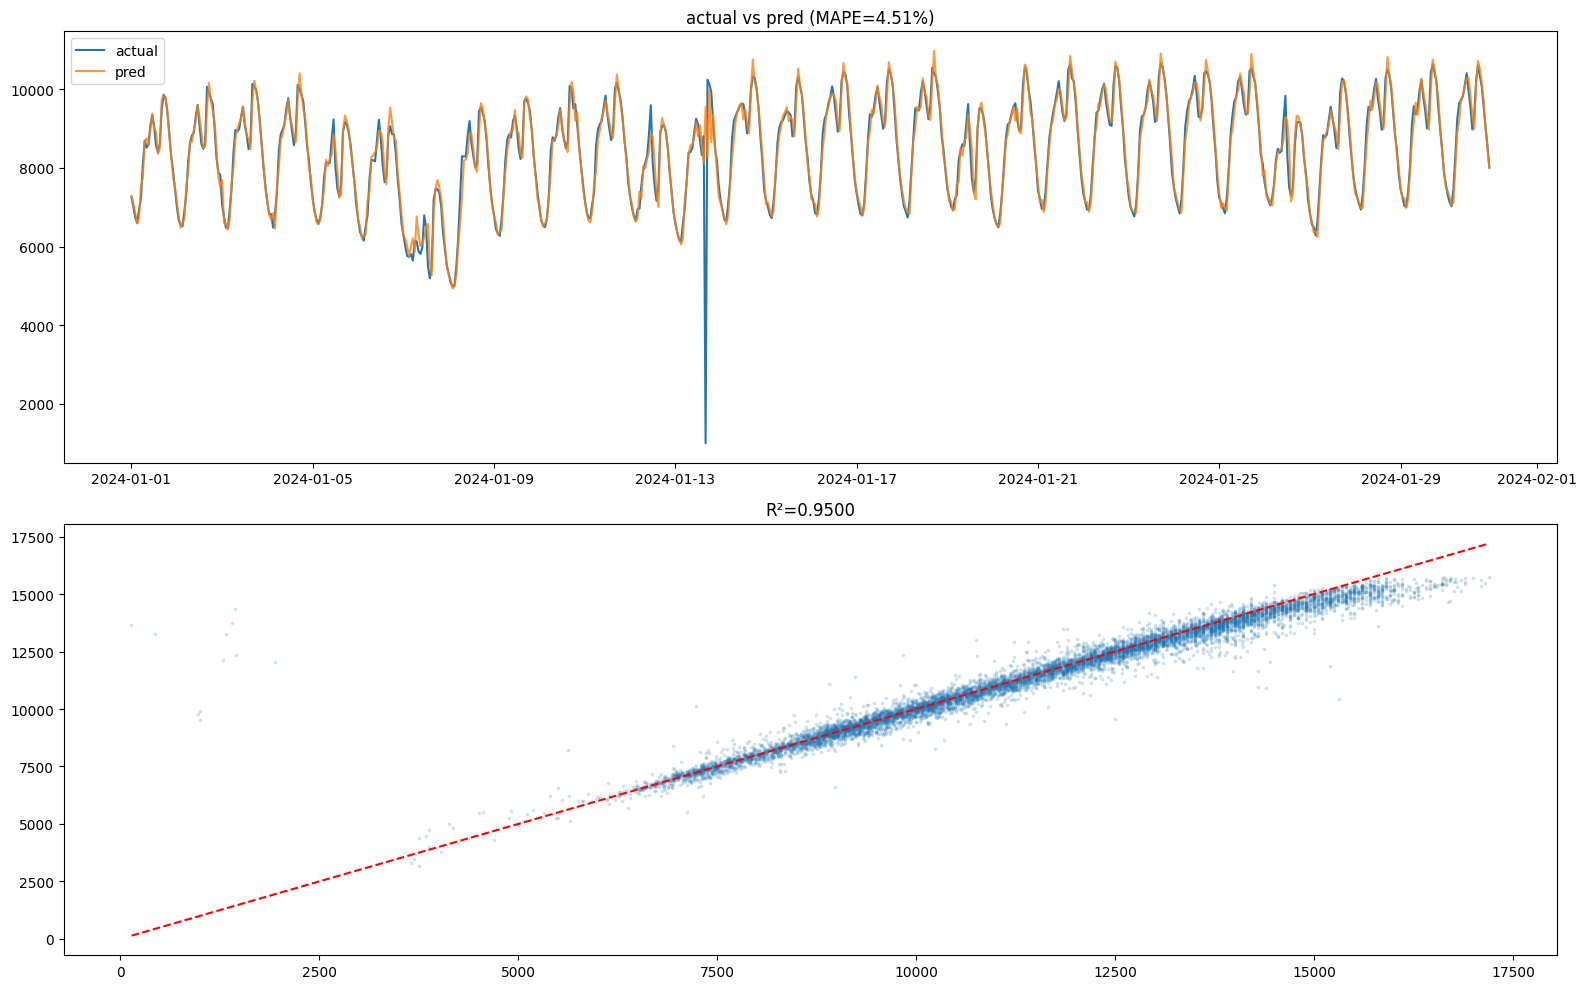

In [ ]:

fig, ax = plt.subplots(2, 1, figsize=(16, 10))


n = 30 * 24
dates = test['datetime'].values[:n]

ax[0].plot(dates, y_test.values[:n], label='actual')
ax[0].plot(dates, gb_prediction[:n], label='pred', alpha=0.8)
ax[0].set_title(f'actual vs pred (MAPE={gb_mape:.2f}%)')
ax[0].legend()


ax[1].scatter(y_test, gb_prediction, alpha=0.15, s=3)
lims = [min(y_test.min(), gb_prediction.min()), max(y_test.max(), gb_prediction.max())]
ax[1].plot(lims, lims, 'r--')
ax[1].set_title(f'R²={r2_score(y_test, gb_prediction):.4f}')

plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=120)
plt.show()

### Feature imp plot

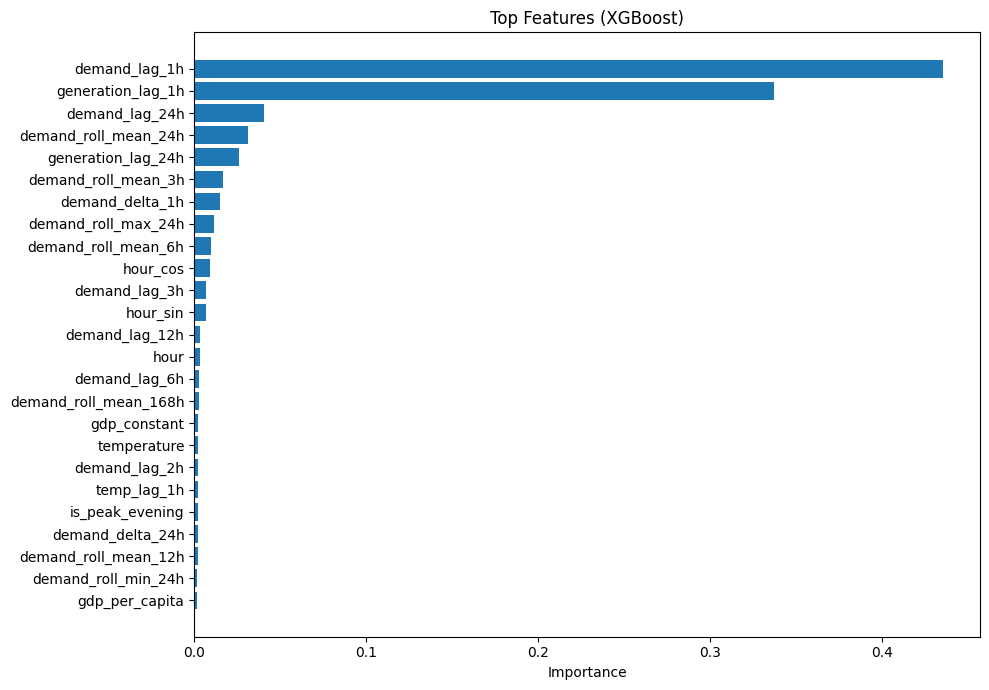

saved: xgb_feature_importance.png


In [ ]:

imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb.feature_importances_   
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 7))

# simple horizontal bar plot
plt.barh(imp['feature'][::-1], imp['importance'][::-1])

plt.title("Top Features (XGBoost)")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=120)
plt.show()


### error analysis plot 

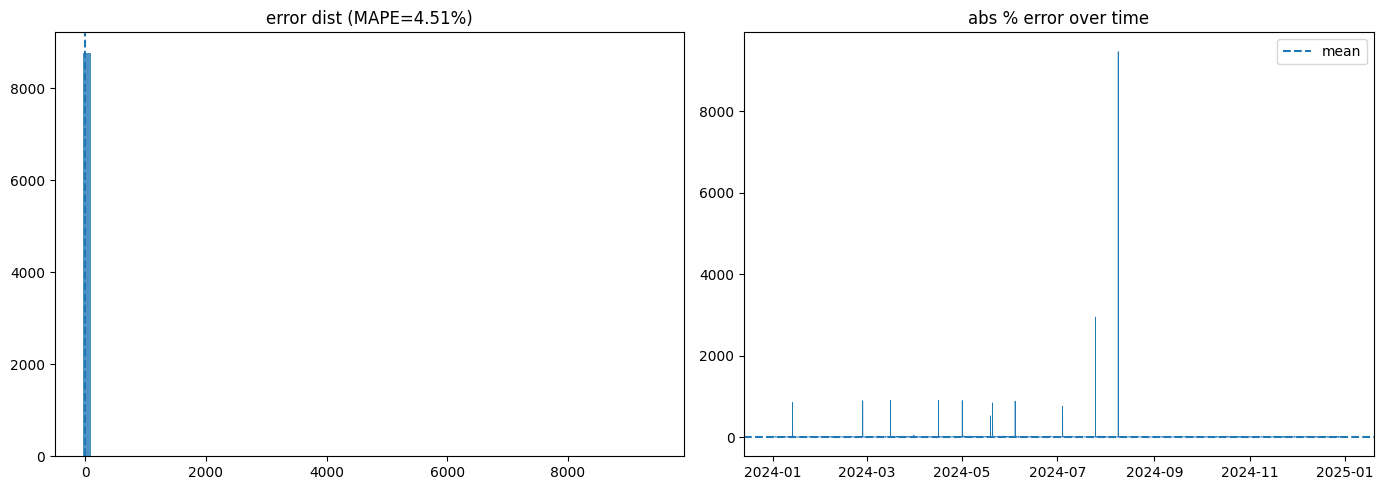

In [ ]:
 

err = gb_prediction - y_test.values
pct_err = (err / y_test.values) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---- histogram ----
ax[0].hist(pct_err, bins=80, alpha=0.8)
ax[0].axvline(0, linestyle='--')
ax[0].set_title(f'error dist (MAPE={gb_mape:.2f}%)')

# ---- error over time ----
ax[1].plot(test['datetime'], np.abs(pct_err), linewidth=0.5)
ax[1].axhline(gb_mape, linestyle='--', label='mean')
ax[1].set_title('abs % error over time')
ax[1].legend()

plt.tight_layout()
plt.savefig("error_dist.png", dpi=120)
plt.show()